# 2 - Modelling dataset build

This notebook builds a modeling table for **March Titled Tuesday games** using:

- player/tournament priors from **February** games
- rolling player form from **previous March games only** (no future leakage)

Then it creates train/validation/test splits and exports matrices ready for scikit-learn and XGBoost.

In [118]:
from pathlib import Path
import json

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

GAMES_PATH = Path("../data/raw/titled_tuesday_games.jsonl")
PLAYERS_PATH = Path("../data/raw/titled_tuesday_players.jsonl")

assert GAMES_PATH.exists(), f"Missing file: {GAMES_PATH}"
assert PLAYERS_PATH.exists(), f"Missing file: {PLAYERS_PATH}"


def read_jsonl(path: Path):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows


games_df = pd.DataFrame(read_jsonl(GAMES_PATH))
players_df = pd.DataFrame(read_jsonl(PLAYERS_PATH))

print("games:", games_df.shape)
print("players:", players_df.shape)
games_df.head(3)

games: (4063, 18)
players: (700, 6)


,tournament_id,round,group,game_url,time_class,time_control,rated,rules,white_username,white_rating,white_result_raw,black_username,black_rating,black_result_raw,eco,start_time,end_time,result_white_pov
0,titled-tuesday-blitz-february-10-2026-6221327,0,0,https://www.chess.com/game/live/165052787661,blitz,300,True,chess,UmutErdemGunduz,2682,timeout,Hikaru,3316,win,https://www.chess.com/openings/Modern-Defense-...,None,1770739793,loss
1,titled-tuesday-blitz-february-10-2026-6221327,0,0,https://www.chess.com/game/live/165052787663,blitz,300,True,chess,lachesisQ,3279,win,GorinDeshi,2678,resigned,https://www.chess.com/openings/Sicilian-Defens...,None,1770739597,win
2,titled-tuesday-blitz-february-10-2026-6221327,0,0,https://www.chess.com/game/live/165052787665,blitz,300,True,chess,JaiSankarS,2677,checkmated,NikoTheodorou,3252,win,https://www.chess.com/openings/English-Opening...,None,1770739602,loss


In [119]:
# Identify tournaments and prepare clean sort order.
all_tournament_ids = sorted(games_df["tournament_id"].dropna().unique().tolist())
print("Tournament IDs:")
for tid in all_tournament_ids:
    print("-", tid)

feb_tid = [t for t in all_tournament_ids if "february" in t.lower()][0]
march_tid = [t for t in all_tournament_ids if "march" in t.lower()][0]

feb_games = games_df[games_df["tournament_id"] == feb_tid].copy()
march_games = games_df[games_df["tournament_id"] == march_tid].copy()

# Build a deterministic order inside tournaments.
for g in (feb_games, march_games):
    g["end_time_num"] = pd.to_numeric(g["end_time"], errors="coerce")
    g["start_time_num"] = pd.to_numeric(g["start_time"], errors="coerce")
    g["sort_time"] = g["end_time_num"].fillna(g["start_time_num"])
    g["sort_time"] = g["sort_time"].fillna(-1)

feb_games = feb_games.sort_values(["round", "group", "sort_time", "game_url"]).reset_index(drop=True)
march_games = march_games.sort_values(["round", "group", "sort_time", "game_url"]).reset_index(drop=True)

feb_games["event_game_index"] = np.arange(len(feb_games))
march_games["event_game_index"] = np.arange(len(march_games))

print("February games:", len(feb_games))
print("March games:", len(march_games))
march_games[["event_game_index", "round", "group", "white_username", "black_username", "result_white_pov"]].head(5)

Tournament IDs:
- titled-tuesday-blitz-february-10-2026-6221327
- titled-tuesday-blitz-march-10-2026-6277141
February games: 2025
March games: 2038


,event_game_index,round,group,white_username,black_username,result_white_pov
0,0,0,0,endgamemaster51,Thehas_Kiringoda,win
1,1,0,0,jazz_0607,aldareee,loss
2,2,0,0,TimAina,tuongminhcute,win
3,3,0,0,SharapovEvgeny,Konavets,loss
4,4,0,0,EternalNight8,AlmasRakhmatullaev,win


In [120]:
# Build static player/time-class features from player stats payload.
TIME_CLASS_TO_STATS_KEY = {
    "bullet": "chess_bullet",
    "blitz": "chess_blitz",
    "rapid": "chess_rapid",
    "daily": "chess_daily",
}


def safe_div(num, den):
    if num is None or pd.isna(num):
        return np.nan
    if den in (None, 0) or pd.isna(den):
        return np.nan
    return num / den


def build_player_stats_features(players: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in players.iterrows():
        username = row.get("username")
        username_key = str(username).lower() if pd.notna(username) else None
        stats = row.get("stats") or {}
        profile = row.get("profile") or {}

        for tc, stats_key in TIME_CLASS_TO_STATS_KEY.items():
            tc_stats = stats.get(stats_key) or {}
            if not isinstance(tc_stats, dict) or len(tc_stats) == 0:
                continue

            last = tc_stats.get("last") or {}
            best = tc_stats.get("best") or {}
            record = tc_stats.get("record") or {}

            w = record.get("win", 0)
            l = record.get("loss", 0)
            d = record.get("draw", 0)
            n = w + l + d

            current = last.get("rating")
            peak = best.get("rating")

            rows.append(
                {
                    "username_key": username_key,
                    "time_class": tc,
                    "stats_current_rating": current,
                    "stats_current_rd": last.get("rd"),
                    "stats_peak_rating": peak,
                    "stats_rating_trend": current - peak if pd.notna(current) and pd.notna(peak) else np.nan,
                    "stats_games": n,
                    "stats_win_rate": safe_div(w, n),
                    "stats_draw_rate": safe_div(d, n),
                    "stats_timeout_percent": tc_stats.get("timeout_percent"),
                    "stats_time_per_move": tc_stats.get("time_per_move"),
                    "stats_fide": stats.get("fide"),
                    "stats_title": profile.get("title"),
                    "stats_followers": profile.get("followers"),
                    "stats_joined": profile.get("joined"),
                }
            )
    return pd.DataFrame(rows)


player_stats_features = build_player_stats_features(players_df)
player_stats_features.head(3)

,username_key,time_class,stats_current_rating,stats_current_rd,stats_peak_rating,stats_rating_trend,stats_games,stats_win_rate,stats_draw_rate,stats_timeout_percent,stats_time_per_move,stats_fide,stats_title,stats_followers,stats_joined
0,7chessace,bullet,2737,45.0,2755.0,-18.0,191,0.581152,0.062827,None,None,2387.0,FM,6,1769023184
1,7chessace,blitz,2904,31.0,2904.0,0.0,331,0.598187,0.096677,None,None,2387.0,FM,6,1769023184
2,a-fier,bullet,2703,48.0,2839.0,-136.0,418,0.540670,0.055024,None,None,2600.0,GM,1847,1361966117


In [121]:
# February prior features from game outcomes.


def to_player_game_rows(games: pd.DataFrame) -> pd.DataFrame:
    white = games[["time_class", "event_game_index", "white_username", "white_rating", "black_rating", "result_white_pov"]].copy()
    white = white.rename(
        columns={
            "white_username": "username",
            "white_rating": "player_rating",
            "black_rating": "opp_rating",
        }
    )
    white["color"] = "white"
    white["score"] = white["result_white_pov"].map({"win": 1.0, "draw": 0.5, "loss": 0.0})

    black = games[["time_class", "event_game_index", "black_username", "black_rating", "white_rating", "result_white_pov"]].copy()
    black = black.rename(
        columns={
            "black_username": "username",
            "black_rating": "player_rating",
            "white_rating": "opp_rating",
        }
    )
    black["color"] = "black"
    black["score"] = black["result_white_pov"].map({"win": 0.0, "draw": 0.5, "loss": 1.0})

    out = pd.concat([white, black], ignore_index=True)
    out["username_key"] = out["username"].str.lower()
    out["is_win"] = (out["score"] == 1.0).astype(int)
    out["is_draw"] = (out["score"] == 0.5).astype(int)
    out["is_loss"] = (out["score"] == 0.0).astype(int)
    out["rating_diff_game"] = out["player_rating"] - out["opp_rating"]
    return out


feb_player_games = to_player_game_rows(feb_games)

feb_prior = (
    feb_player_games.groupby(["username_key", "time_class"], as_index=False)
    .agg(
        feb_games_played=("score", "size"),
        feb_score_mean=("score", "mean"),
        feb_win_rate=("is_win", "mean"),
        feb_draw_rate=("is_draw", "mean"),
        feb_loss_rate=("is_loss", "mean"),
        feb_avg_rating_diff=("rating_diff_game", "mean"),
    )
)

feb_prior.head(3)

,username_key,time_class,feb_games_played,feb_score_mean,feb_win_rate,feb_draw_rate,feb_loss_rate,feb_avg_rating_diff
0,a-fier,blitz,11,0.636364,0.636364,0.0,0.363636,271.545455
1,aa175,blitz,2,0.500000,0.500000,0.0,0.500000,349.000000
2,aamuktha-guntaka,blitz,10,0.350000,0.300000,0.1,0.600000,-98.200000


In [122]:
# March rolling form features using only previous games in March.
march_player_games = to_player_game_rows(march_games).sort_values(["username_key", "time_class", "event_game_index"]).copy()

# Previous-game-only cumulative features.
grp = march_player_games.groupby(["username_key", "time_class"], sort=False)

march_player_games["m_prev_games"] = grp.cumcount()
march_player_games["m_prev_score_sum"] = grp["score"].cumsum() - march_player_games["score"]
march_player_games["m_prev_win_sum"] = grp["is_win"].cumsum() - march_player_games["is_win"]
march_player_games["m_prev_draw_sum"] = grp["is_draw"].cumsum() - march_player_games["is_draw"]
march_player_games["m_prev_loss_sum"] = grp["is_loss"].cumsum() - march_player_games["is_loss"]

march_player_games["m_prev_score_rate"] = np.where(
    march_player_games["m_prev_games"] > 0,
    march_player_games["m_prev_score_sum"] / march_player_games["m_prev_games"],
    np.nan,
)
march_player_games["m_prev_win_rate"] = np.where(
    march_player_games["m_prev_games"] > 0,
    march_player_games["m_prev_win_sum"] / march_player_games["m_prev_games"],
    np.nan,
)
march_player_games["m_prev_draw_rate"] = np.where(
    march_player_games["m_prev_games"] > 0,
    march_player_games["m_prev_draw_sum"] / march_player_games["m_prev_games"],
    np.nan,
)

# Color-specific rolling score.
for color in ["white", "black"]:
    mask = march_player_games["color"] == color
    sub = march_player_games.loc[mask, ["username_key", "time_class", "event_game_index", "score"]].copy()
    sub = sub.sort_values(["username_key", "time_class", "event_game_index"])
    g2 = sub.groupby(["username_key", "time_class"], sort=False)
    sub["prev_color_games"] = g2.cumcount()
    sub["prev_color_score_sum"] = g2["score"].cumsum() - sub["score"]
    sub["prev_color_score_rate"] = np.where(
        sub["prev_color_games"] > 0,
        sub["prev_color_score_sum"] / sub["prev_color_games"],
        np.nan,
    )
    march_player_games.loc[mask, f"m_prev_{color}_score_rate"] = sub["prev_color_score_rate"].values

rolling_cols = [
    "event_game_index",
    "username_key",
    "time_class",
    "m_prev_games",
    "m_prev_score_rate",
    "m_prev_win_rate",
    "m_prev_draw_rate",
    "m_prev_white_score_rate",
    "m_prev_black_score_rate",
]

march_rolling = march_player_games[rolling_cols].copy()
march_rolling.head(3)

,event_game_index,username_key,time_class,m_prev_games,m_prev_score_rate,m_prev_win_rate,m_prev_draw_rate,m_prev_white_score_rate,m_prev_black_score_rate
2087,49,7chessace,blitz,0,NaN,NaN,NaN,NaN,NaN
2275,237,7chessace,blitz,1,1.0,1.0,0.0,NaN,1.0
451,451,7chessace,blitz,2,0.5,0.5,0.0,NaN,NaN


In [123]:
# Merge all feature sources into March game-level modeling frame.
model_games = march_games.copy()
model_games["white_username_key"] = model_games["white_username"].str.lower()
model_games["black_username_key"] = model_games["black_username"].str.lower()

# Merge static player stats.
w_static = player_stats_features.add_prefix("w_")
b_static = player_stats_features.add_prefix("b_")

model_games = model_games.merge(
    w_static,
    left_on=["white_username_key", "time_class"],
    right_on=["w_username_key", "w_time_class"],
    how="left",
)
model_games = model_games.merge(
    b_static,
    left_on=["black_username_key", "time_class"],
    right_on=["b_username_key", "b_time_class"],
    how="left",
)

# Merge February priors.
w_feb = feb_prior.add_prefix("w_")
b_feb = feb_prior.add_prefix("b_")
model_games = model_games.merge(
    w_feb,
    left_on=["white_username_key", "time_class"],
    right_on=["w_username_key", "w_time_class"],
    how="left",
)
model_games = model_games.merge(
    b_feb,
    left_on=["black_username_key", "time_class"],
    right_on=["b_username_key", "b_time_class"],
    how="left",
)

# Merge rolling March priors keyed by exact game index.
w_roll = march_rolling.add_prefix("w_")
b_roll = march_rolling.add_prefix("b_")
model_games = model_games.merge(
    w_roll,
    left_on=["event_game_index", "white_username_key", "time_class"],
    right_on=["w_event_game_index", "w_username_key", "w_time_class"],
    how="left",
)
model_games = model_games.merge(
    b_roll,
    left_on=["event_game_index", "black_username_key", "time_class"],
    right_on=["b_event_game_index", "b_username_key", "b_time_class"],
    how="left",
)

# Build matchup deltas (white minus black).
delta_pairs = [
    ("stats_current_rating", "rating_delta"),
    ("stats_current_rd", "rd_delta"),
    ("stats_peak_rating", "peak_rating_delta"),
    ("stats_rating_trend", "rating_trend_delta"),
    ("stats_win_rate", "stats_win_rate_delta"),
    ("stats_draw_rate", "stats_draw_rate_delta"),
    ("stats_games", "stats_games_delta"),
    ("stats_timeout_percent", "timeout_percent_delta"),
    ("stats_time_per_move", "time_per_move_delta"),
    ("stats_fide", "fide_delta"),
    ("stats_followers", "followers_delta"),
    ("stats_joined", "joined_ts_delta"),
    ("feb_games_played", "feb_games_played_delta"),
    ("feb_score_mean", "feb_score_mean_delta"),
    ("feb_win_rate", "feb_win_rate_delta"),
    ("feb_draw_rate", "feb_draw_rate_delta"),
    ("feb_avg_rating_diff", "feb_avg_rating_diff_delta"),
    ("m_prev_games", "m_prev_games_delta"),
    ("m_prev_score_rate", "m_prev_score_rate_delta"),
    ("m_prev_win_rate", "m_prev_win_rate_delta"),
    ("m_prev_draw_rate", "m_prev_draw_rate_delta"),
    ("m_prev_white_score_rate", "m_prev_white_score_rate_delta"),
    ("m_prev_black_score_rate", "m_prev_black_score_rate_delta"),
]

for base_col, out_col in delta_pairs:
    model_games[out_col] = model_games[f"w_{base_col}"] - model_games[f"b_{base_col}"]

model_games["title_delta"] = model_games["w_stats_title"].notna().astype(int) - model_games["b_stats_title"].notna().astype(int)
model_games["white_advantage_prior"] = 1.0

model_games[["event_game_index", "white_username", "black_username", "result_white_pov", "rating_delta", "m_prev_score_rate_delta", "feb_score_mean_delta"]].head(5)

,event_game_index,white_username,black_username,result_white_pov,rating_delta,m_prev_score_rate_delta,feb_score_mean_delta
0,0,endgamemaster51,Thehas_Kiringoda,win,316,NaN,NaN
1,1,jazz_0607,aldareee,loss,-778,NaN,NaN
2,2,TimAina,tuongminhcute,win,418,NaN,NaN
3,3,SharapovEvgeny,Konavets,loss,-521,NaN,NaN
4,4,EternalNight8,AlmasRakhmatullaev,win,-496,NaN,NaN


In [124]:
# Final modeling dataframe.

feature_cols = [
    "white_advantage_prior",
    "rating_delta",
    "rd_delta",
    "peak_rating_delta",
    "rating_trend_delta",
    "stats_win_rate_delta",
    "stats_draw_rate_delta",
    "stats_games_delta",
    "timeout_percent_delta",
    "time_per_move_delta",
    "fide_delta",
    "followers_delta",
    "joined_ts_delta",
    "title_delta",
    "feb_games_played_delta",
    "feb_score_mean_delta",
    "feb_win_rate_delta",
    "feb_draw_rate_delta",
    "feb_avg_rating_diff_delta",
    "m_prev_games_delta",
    "m_prev_score_rate_delta",
    "m_prev_win_rate_delta",
    "m_prev_draw_rate_delta",
    "m_prev_white_score_rate_delta",
    "m_prev_black_score_rate_delta",
]

model_df = model_games[
    [
        "event_game_index",
        "tournament_id",
        "round",
        "group",
        "game_url",
        "time_class",
        "white_username",
        "black_username",
        "result_white_pov",
    ]
    + feature_cols
].copy()

# Target encoding for sklearn/xgboost multiclass.
y_map = {"loss": 0, "draw": 1, "win": 2}
model_df["y"] = model_df["result_white_pov"].map(y_map)

# Ensure all model features are numeric for sklearn/xgboost compatibility.
for col in feature_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

print("Model dataframe shape:", model_df.shape)
print("Feature dtypes summary:")
print(model_df[feature_cols].dtypes.value_counts())
print("Missingness (top 10):")
print(model_df[feature_cols].isna().mean().sort_values(ascending=False).head(10))
model_df.head(3)

Model dataframe shape: (2038, 35)
Feature dtypes summary:
float64    19
int64       6
Name: count, dtype: int64
Missingness (top 10):
m_prev_black_score_rate_delta    1.000000
m_prev_white_score_rate_delta    1.000000
timeout_percent_delta            1.000000
time_per_move_delta              1.000000
feb_games_played_delta           0.748283
feb_avg_rating_diff_delta        0.748283
feb_draw_rate_delta              0.748283
feb_win_rate_delta               0.748283
feb_score_mean_delta             0.748283
fide_delta                       0.394504
dtype: float64


,event_game_index,tournament_id,round,group,game_url,time_class,white_username,black_username,result_white_pov,white_advantage_prior,rating_delta,rd_delta,peak_rating_delta,rating_trend_delta,stats_win_rate_delta,stats_draw_rate_delta,stats_games_delta,timeout_percent_delta,time_per_move_delta,fide_delta,followers_delta,joined_ts_delta,title_delta,feb_games_played_delta,feb_score_mean_delta,feb_win_rate_delta,feb_draw_rate_delta,feb_avg_rating_diff_delta,m_prev_games_delta,m_prev_score_rate_delta,m_prev_win_rate_delta,m_prev_draw_rate_delta,m_prev_white_score_rate_delta,m_prev_black_score_rate_delta,y
0,0,titled-tuesday-blitz-march-10-2026-6277141,0,0,https://www.chess.com/game/live/167472014475,blitz,endgamemaster51,Thehas_Kiringoda,win,1.0,316,-33.0,383.0,-67.0,-0.295996,0.083776,7722,NaN,NaN,178.0,30,126429980,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,2
1,1,titled-tuesday-blitz-march-10-2026-6277141,0,0,https://www.chess.com/game/live/167472014739,blitz,jazz_0607,aldareee,loss,1.0,-778,38.0,-858.0,80.0,-0.402192,-0.057279,-2294,NaN,NaN,-266.0,-53,31144989,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0
2,2,titled-tuesday-blitz-march-10-2026-6277141,0,0,https://www.chess.com/game/live/167472014383,blitz,TimAina,tuongminhcute,win,1.0,418,-7.0,496.0,-78.0,-0.039203,0.018265,1850,NaN,NaN,NaN,-82,5374231,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,2


In [125]:
# Train/validation/test split (chronological inside March).
# Because all rows are March games, we split by event_game_index to respect time order.
model_df = model_df.sort_values("event_game_index").reset_index(drop=True)

n = len(model_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[train_end:val_end].copy()
test_df = model_df.iloc[val_end:].copy()

print(f"train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
print("Class balance train:")
print(train_df["y"].value_counts(normalize=True).sort_index())

# Imputation: median from train only, then deterministic fallback for all-NaN columns.
train_medians = train_df[feature_cols].median(numeric_only=True)
train_medians = train_medians.fillna(0.0)

def make_xy(df_part: pd.DataFrame):
    X = df_part[feature_cols].copy()
    X = X.fillna(train_medians)
    X = X.fillna(0.0)  # final guard if any column still has NaN
    X = X.astype(float)
    y = df_part["y"].astype(int).to_numpy()
    return X, y

X_train, y_train = make_xy(train_df)
X_val, y_val = make_xy(val_df)
X_test, y_test = make_xy(test_df)

print("Shapes:")
print("X_train", X_train.shape, "X_val", X_val.shape, "X_test", X_test.shape)
print("Remaining NaNs:", int(X_train.isna().sum().sum() + X_val.isna().sum().sum() + X_test.isna().sum().sum()))
X_train.head(2)

train=1426, val=306, test=306
Class balance train:
y
0    0.457924
1    0.065919
2    0.476157
Name: proportion, dtype: float64
Shapes:
X_train (1426, 25) X_val (306, 25) X_test (306, 25)
Remaining NaNs: 0


,white_advantage_prior,rating_delta,rd_delta,peak_rating_delta,rating_trend_delta,stats_win_rate_delta,stats_draw_rate_delta,stats_games_delta,timeout_percent_delta,time_per_move_delta,fide_delta,followers_delta,joined_ts_delta,title_delta,feb_games_played_delta,feb_score_mean_delta,feb_win_rate_delta,feb_draw_rate_delta,feb_avg_rating_diff_delta,m_prev_games_delta,m_prev_score_rate_delta,m_prev_win_rate_delta,m_prev_draw_rate_delta,m_prev_white_score_rate_delta,m_prev_black_score_rate_delta
0,1.0,316.0,-33.0,383.0,-67.0,-0.295996,0.083776,7722.0,0.0,0.0,178.0,30.0,126429980.0,0.0,0.0,0.0,0.0,0.0,4.818182,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,-778.0,38.0,-858.0,80.0,-0.402192,-0.057279,-2294.0,0.0,0.0,-266.0,-53.0,31144989.0,0.0,0.0,0.0,0.0,0.0,4.818182,0.0,0.0,0.0,0.0,0.0,0.0


In [126]:
# Formats for scikit-learn and xgboost.

# scikit-learn-ready objects (pandas DataFrame + numpy target arrays)
sklearn_bundle = {
    "X_train": X_train,
    "y_train": y_train,
    "X_val": X_val,
    "y_val": y_val,
    "X_test": X_test,
    "y_test": y_test,
    "feature_names": feature_cols,
    "class_map": {0: "loss", 1: "draw", 2: "win"},
}

print("sklearn bundle ready")

# xgboost-ready objects (DMatrix), if xgboost is installed.
try:
    import xgboost as xgb

    dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=feature_cols)
    dval = xgb.DMatrix(X_val, label=y_val, feature_names=feature_cols)
    dtest = xgb.DMatrix(X_test, label=y_test, feature_names=feature_cols)

    xgb_bundle = {
        "dtrain": dtrain,
        "dval": dval,
        "dtest": dtest,
        "num_class": 3,
        "objective": "multi:softprob",
        "eval_metric": "mlogloss",
    }
    print("xgboost bundle ready")
except Exception as exc:
    xgb_bundle = None
    print("xgboost not available or DMatrix failed:", exc)

sklearn bundle ready
xgboost bundle ready


## Baseline models: Logistic, Random Forest, XGBoost

Train three multiclass baselines on the same splits and compare:

- multiclass log loss
- macro F1
- accuracy

In [127]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, f1_score, accuracy_score, balanced_accuracy_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight

results = []
trained_models = {}

# Inverse-frequency sample weights to emphasize minority classes (draw).
train_sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)
val_sample_weight = compute_sample_weight(class_weight="balanced", y=y_val)


def _class_accuracy(y_true, y_pred, class_id):
    mask = y_true == class_id
    if mask.sum() == 0:
        return float("nan")
    return float((y_pred[mask] == class_id).mean())


def evaluate_model(name, model, X_tr, y_tr, X_va, y_va, X_te, y_te, fit_kwargs=None):
    fit_kwargs = fit_kwargs or {}
    model.fit(X_tr, y_tr, **fit_kwargs)

    val_pred = model.predict(X_va)
    test_pred = model.predict(X_te)

    val_prob = model.predict_proba(X_va)
    test_prob = model.predict_proba(X_te)

    row = {
        "model": name,
        "val_logloss": log_loss(y_va, val_prob, labels=[0, 1, 2]),
        "val_macro_f1": f1_score(y_va, val_pred, average="macro"),
        "val_accuracy": accuracy_score(y_va, val_pred),
        "val_balanced_accuracy": balanced_accuracy_score(y_va, val_pred),
        "val_loss_accuracy": _class_accuracy(y_va, val_pred, 0),
        "val_draw_accuracy": _class_accuracy(y_va, val_pred, 1),
        "val_win_accuracy": _class_accuracy(y_va, val_pred, 2),
        "test_logloss": log_loss(y_te, test_prob, labels=[0, 1, 2]),
        "test_macro_f1": f1_score(y_te, test_pred, average="macro"),
        "test_accuracy": accuracy_score(y_te, test_pred),
        "test_balanced_accuracy": balanced_accuracy_score(y_te, test_pred),
        "test_loss_accuracy": _class_accuracy(y_te, test_pred, 0),
        "test_draw_accuracy": _class_accuracy(y_te, test_pred, 1),
        "test_win_accuracy": _class_accuracy(y_te, test_pred, 2),
    }
    results.append(row)
    trained_models[name] = model


# 1) Multinomial logistic regression (with scaling)
logreg = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "clf",
            LogisticRegression(
                solver="lbfgs",
                max_iter=2000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)
evaluate_model("logistic_multinomial", logreg, X_train, y_train, X_val, y_val, X_test, y_test)

# 2) Random forest
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)
evaluate_model("random_forest", rf, X_train, y_train, X_val, y_val, X_test, y_test)

# 3) XGBoost (if available)
try:
    import xgboost as xgb

    xgb_model = xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
    )
    evaluate_model(
        "xgboost",
        xgb_model,
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test,
        fit_kwargs={"sample_weight": train_sample_weight},
    )
except Exception as exc:
    print("Skipping XGBoost:", exc)

results_df = pd.DataFrame(results).sort_values("val_logloss")
results_df

,model,val_logloss,val_macro_f1,val_accuracy,val_balanced_accuracy,val_loss_accuracy,val_draw_accuracy,val_win_accuracy,test_logloss,test_macro_f1,test_accuracy,test_balanced_accuracy,test_loss_accuracy,test_draw_accuracy,test_win_accuracy
1,random_forest,0.857146,0.435071,0.624183,0.453634,0.658915,0.000000,0.701987,0.878549,0.431401,0.614379,0.455065,0.723404,0.000000,0.641791
0,logistic_multinomial,1.041039,0.424811,0.506536,0.419699,0.503876,0.192308,0.562914,1.064367,0.433753,0.516340,0.432128,0.602837,0.193548,0.500000
2,xgboost,1.075124,0.450763,0.614379,0.458754,0.682171,0.038462,0.655629,1.054742,0.416936,0.565359,0.427128,0.659574,0.032258,0.589552


In [128]:
# Detailed report for best validation model (balanced selection).
selection_metric = "val_balanced_accuracy"
best_model_name = results_df.sort_values(selection_metric, ascending=False).iloc[0]["model"]
best_model = trained_models[best_model_name]

val_pred_best = best_model.predict(X_val)
test_pred_best = best_model.predict(X_test)

print(f"Best model by {selection_metric}:", best_model_name)
print("\nValidation classification report")
print(classification_report(y_val, val_pred_best, target_names=["loss", "draw", "win"]))

print("\nTest classification report")
print(classification_report(y_test, test_pred_best, target_names=["loss", "draw", "win"]))

Best model: random_forest

Validation classification report
              precision    recall  f1-score   support

        loss       0.61      0.66      0.63       129
        draw       0.00      0.00      0.00        26
         win       0.64      0.70      0.67       151

    accuracy                           0.62       306
   macro avg       0.42      0.45      0.44       306
weighted avg       0.57      0.62      0.60       306


Test classification report
              precision    recall  f1-score   support

        loss       0.63      0.72      0.68       141
        draw       0.00      0.00      0.00        31
         win       0.60      0.64      0.62       134

    accuracy                           0.61       306
   macro avg       0.41      0.46      0.43       306
weighted avg       0.55      0.61      0.58       306



## Stronger baselines, early stopping, calibration

Add:
- a majority-class baseline (reference log loss)
- a rating-only logistic baseline (pure Elo-style signal)
- XGBoost with early stopping + gentler hyperparameters
- HistGradientBoosting (native NaN support)
- Probability calibration for tree models

In [129]:
# Baseline references: class prior and rating-only logistic.
from sklearn.dummy import DummyClassifier
from sklearn.metrics import balanced_accuracy_score


def _class_accuracy(y_true, y_pred, class_id):
    mask = y_true == class_id
    if mask.sum() == 0:
        return float("nan")
    return float((y_pred[mask] == class_id).mean())


def eval_probs(name, p_val, pred_val, p_test, pred_test):
    row = {
        "model": name,
        "val_logloss": log_loss(y_val, p_val, labels=[0, 1, 2]),
        "val_macro_f1": f1_score(y_val, pred_val, average="macro"),
        "val_accuracy": accuracy_score(y_val, pred_val),
        "val_balanced_accuracy": balanced_accuracy_score(y_val, pred_val),
        "val_loss_accuracy": _class_accuracy(y_val, pred_val, 0),
        "val_draw_accuracy": _class_accuracy(y_val, pred_val, 1),
        "val_win_accuracy": _class_accuracy(y_val, pred_val, 2),
        "test_logloss": log_loss(y_test, p_test, labels=[0, 1, 2]),
        "test_macro_f1": f1_score(y_test, pred_test, average="macro"),
        "test_accuracy": accuracy_score(y_test, pred_test),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, pred_test),
        "test_loss_accuracy": _class_accuracy(y_test, pred_test, 0),
        "test_draw_accuracy": _class_accuracy(y_test, pred_test, 1),
        "test_win_accuracy": _class_accuracy(y_test, pred_test, 2),
    }
    results.append(row)


# 1) Majority-class baseline (prior frequencies from train).
prior = DummyClassifier(strategy="prior")
prior.fit(X_train, y_train)
p_val = prior.predict_proba(X_val)
p_test = prior.predict_proba(X_test)
pred_val = prior.predict(X_val)
pred_test = prior.predict(X_test)
eval_probs("baseline_class_prior", p_val, pred_val, p_test, pred_test)
trained_models["baseline_class_prior"] = prior

# 2) Rating-only logistic baseline (only rating_delta).
rating_only = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "clf",
            LogisticRegression(
                solver="lbfgs",
                max_iter=2000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)
rating_only.fit(X_train[["rating_delta"]], y_train)
p_val = rating_only.predict_proba(X_val[["rating_delta"]])
p_test = rating_only.predict_proba(X_test[["rating_delta"]])
pred_val = rating_only.predict(X_val[["rating_delta"]])
pred_test = rating_only.predict(X_test[["rating_delta"]])
eval_probs("rating_only_logistic", p_val, pred_val, p_test, pred_test)
trained_models["rating_only_logistic"] = rating_only

pd.DataFrame(results).sort_values("val_logloss")

,model,val_logloss,val_macro_f1,val_accuracy,val_balanced_accuracy,val_loss_accuracy,val_draw_accuracy,val_win_accuracy,test_logloss,test_macro_f1,test_accuracy,test_balanced_accuracy,test_loss_accuracy,test_draw_accuracy,test_win_accuracy
1,random_forest,0.857146,0.435071,0.624183,0.453634,0.658915,0.000000,0.701987,0.878549,0.431401,0.614379,0.455065,0.723404,0.000000,0.641791
3,baseline_class_prior,0.926475,0.220277,0.493464,0.333333,0.000000,0.000000,1.000000,0.960316,0.203030,0.437908,0.333333,0.000000,0.000000,1.000000
4,rating_only_logistic,1.011851,0.450868,0.555556,0.444458,0.550388,0.153846,0.629139,1.047866,0.445954,0.535948,0.446683,0.624113,0.193548,0.522388
0,logistic_multinomial,1.041039,0.424811,0.506536,0.419699,0.503876,0.192308,0.562914,1.064367,0.433753,0.516340,0.432128,0.602837,0.193548,0.500000
2,xgboost,1.075124,0.450763,0.614379,0.458754,0.682171,0.038462,0.655629,1.054742,0.416936,0.565359,0.427128,0.659574,0.032258,0.589552


In [130]:
# XGBoost with early stopping and conservative hyperparameters.
try:
    import xgboost as xgb

    xgb_es = xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=2.0,
        reg_alpha=0.0,
        gamma=0.0,
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=50,
    )
    xgb_es.fit(
        X_train,
        y_train,
        sample_weight=train_sample_weight,
        eval_set=[(X_val, y_val)],
        sample_weight_eval_set=[val_sample_weight],
        verbose=False,
    )
    trained_models["xgboost_early_stop"] = xgb_es

    p_val = xgb_es.predict_proba(X_val)
    p_test = xgb_es.predict_proba(X_test)
    pred_val = xgb_es.predict(X_val)
    pred_test = xgb_es.predict(X_test)
    eval_probs("xgboost_early_stop", p_val, pred_val, p_test, pred_test)

    print("Best iteration:", getattr(xgb_es, "best_iteration", None))
except Exception as exc:
    print("XGBoost early-stop run failed:", exc)

pd.DataFrame(results).sort_values("val_logloss")

Best iteration: 33


,model,val_logloss,val_macro_f1,val_accuracy,val_balanced_accuracy,val_loss_accuracy,val_draw_accuracy,val_win_accuracy,test_logloss,test_macro_f1,test_accuracy,test_balanced_accuracy,test_loss_accuracy,test_draw_accuracy,test_win_accuracy
1,random_forest,0.857146,0.435071,0.624183,0.453634,0.658915,0.000000,0.701987,0.878549,0.431401,0.614379,0.455065,0.723404,0.000000,0.641791
3,baseline_class_prior,0.926475,0.220277,0.493464,0.333333,0.000000,0.000000,1.000000,0.960316,0.203030,0.437908,0.333333,0.000000,0.000000,1.000000
4,rating_only_logistic,1.011851,0.450868,0.555556,0.444458,0.550388,0.153846,0.629139,1.047866,0.445954,0.535948,0.446683,0.624113,0.193548,0.522388
5,xgboost_early_stop,1.029420,0.422655,0.496732,0.425572,0.542636,0.230769,0.503311,1.029666,0.427023,0.480392,0.446708,0.567376,0.354839,0.417910
0,logistic_multinomial,1.041039,0.424811,0.506536,0.419699,0.503876,0.192308,0.562914,1.064367,0.433753,0.516340,0.432128,0.602837,0.193548,0.500000
2,xgboost,1.075124,0.450763,0.614379,0.458754,0.682171,0.038462,0.655629,1.054742,0.416936,0.565359,0.427128,0.659574,0.032258,0.589552


In [131]:
# HistGradientBoosting (fast, strong tabular baseline, native NaN support).
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=600,
    max_depth=None,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=1.0,
    random_state=42,
    early_stopping=True,
    validation_fraction=None,
)

# Fit with class-balanced sample weights to upweight minority classes.
hgb.fit(X_train, y_train, sample_weight=train_sample_weight)
trained_models["hist_gbm"] = hgb

p_val = hgb.predict_proba(X_val)
p_test = hgb.predict_proba(X_test)
pred_val = hgb.predict(X_val)
pred_test = hgb.predict(X_test)
eval_probs("hist_gbm", p_val, pred_val, p_test, pred_test)

pd.DataFrame(results).sort_values("val_logloss")

,model,val_logloss,val_macro_f1,val_accuracy,val_balanced_accuracy,val_loss_accuracy,val_draw_accuracy,val_win_accuracy,test_logloss,test_macro_f1,test_accuracy,test_balanced_accuracy,test_loss_accuracy,test_draw_accuracy,test_win_accuracy
1,random_forest,0.857146,0.435071,0.624183,0.453634,0.658915,0.000000,0.701987,0.878549,0.431401,0.614379,0.455065,0.723404,0.000000,0.641791
3,baseline_class_prior,0.926475,0.220277,0.493464,0.333333,0.000000,0.000000,1.000000,0.960316,0.203030,0.437908,0.333333,0.000000,0.000000,1.000000
4,rating_only_logistic,1.011851,0.450868,0.555556,0.444458,0.550388,0.153846,0.629139,1.047866,0.445954,0.535948,0.446683,0.624113,0.193548,0.522388
5,xgboost_early_stop,1.029420,0.422655,0.496732,0.425572,0.542636,0.230769,0.503311,1.029666,0.427023,0.480392,0.446708,0.567376,0.354839,0.417910
0,logistic_multinomial,1.041039,0.424811,0.506536,0.419699,0.503876,0.192308,0.562914,1.064367,0.433753,0.516340,0.432128,0.602837,0.193548,0.500000
2,xgboost,1.075124,0.450763,0.614379,0.458754,0.682171,0.038462,0.655629,1.054742,0.416936,0.565359,0.427128,0.659574,0.032258,0.589552
6,hist_gbm,1.456393,0.464703,0.611111,0.466406,0.666667,0.076923,0.655629,1.471072,0.438420,0.575163,0.442609,0.673759,0.064516,0.589552


In [132]:
# Draw-aware random forest: tune class weight + draw threshold.
import numpy as np


def predict_with_draw_threshold(proba, classes, draw_class=1, draw_threshold=0.30):
    classes = np.asarray(classes)
    draw_idx = int(np.where(classes == draw_class)[0][0])

    pred_idx = np.argmax(proba, axis=1)
    draw_mask = proba[:, draw_idx] >= draw_threshold
    pred_idx[draw_mask] = draw_idx
    return classes[pred_idx]


rf_draw_weights = [2.0, 3.0, 4.0, 5.0, 6.0]
rf_draw_thresholds = [0.20, 0.25, 0.30, 0.35, 0.40]

best = None
best_rf = None

for w_draw in rf_draw_weights:
    rf_candidate = RandomForestClassifier(
        n_estimators=800,
        max_depth=None,
        min_samples_leaf=5,
        class_weight={0: 1.0, 1: w_draw, 2: 1.0},
        random_state=42,
        n_jobs=-1,
    )
    rf_candidate.fit(X_train, y_train)

    val_prob = rf_candidate.predict_proba(X_val)

    for t_draw in rf_draw_thresholds:
        val_pred = predict_with_draw_threshold(
            val_prob,
            rf_candidate.classes_,
            draw_class=1,
            draw_threshold=t_draw,
        )

        score = f1_score(y_val, val_pred, average="macro")
        if (best is None) or (score > best["val_macro_f1"]):
            best = {"w_draw": w_draw, "t_draw": t_draw, "val_macro_f1": score}
            best_rf = rf_candidate

print("Best RF draw setup:", best)

# Evaluate chosen draw-aware setup.
p_val = best_rf.predict_proba(X_val)
p_test = best_rf.predict_proba(X_test)
pred_val = predict_with_draw_threshold(p_val, best_rf.classes_, draw_class=1, draw_threshold=best["t_draw"])
pred_test = predict_with_draw_threshold(p_test, best_rf.classes_, draw_class=1, draw_threshold=best["t_draw"])

eval_probs("random_forest_draw_aware", p_val, pred_val, p_test, pred_test)
trained_models["random_forest_draw_aware"] = best_rf

pd.DataFrame(results).sort_values("val_macro_f1", ascending=False).head(10)

Best RF draw setup: {'w_draw': 4.0, 't_draw': 0.3, 'val_macro_f1': 0.4813274311645647}


,model,val_logloss,val_macro_f1,val_accuracy,val_balanced_accuracy,val_loss_accuracy,val_draw_accuracy,val_win_accuracy,test_logloss,test_macro_f1,test_accuracy,test_balanced_accuracy,test_loss_accuracy,test_draw_accuracy,test_win_accuracy
7,random_forest_draw_aware,0.865693,0.481327,0.617647,0.480681,0.651163,0.115385,0.675497,0.890174,0.442910,0.601307,0.453380,0.723404,0.032258,0.604478
6,hist_gbm,1.456393,0.464703,0.611111,0.466406,0.666667,0.076923,0.655629,1.471072,0.438420,0.575163,0.442609,0.673759,0.064516,0.589552
4,rating_only_logistic,1.011851,0.450868,0.555556,0.444458,0.550388,0.153846,0.629139,1.047866,0.445954,0.535948,0.446683,0.624113,0.193548,0.522388
2,xgboost,1.075124,0.450763,0.614379,0.458754,0.682171,0.038462,0.655629,1.054742,0.416936,0.565359,0.427128,0.659574,0.032258,0.589552
1,random_forest,0.857146,0.435071,0.624183,0.453634,0.658915,0.000000,0.701987,0.878549,0.431401,0.614379,0.455065,0.723404,0.000000,0.641791
0,logistic_multinomial,1.041039,0.424811,0.506536,0.419699,0.503876,0.192308,0.562914,1.064367,0.433753,0.516340,0.432128,0.602837,0.193548,0.500000
5,xgboost_early_stop,1.029420,0.422655,0.496732,0.425572,0.542636,0.230769,0.503311,1.029666,0.427023,0.480392,0.446708,0.567376,0.354839,0.417910
3,baseline_class_prior,0.926475,0.220277,0.493464,0.333333,0.000000,0.000000,1.000000,0.960316,0.203030,0.437908,0.333333,0.000000,0.000000,1.000000


In [133]:
# Probability calibration for the tree models.
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

def calibrate(fitted_model, name, method="isotonic"):
    """Calibrate a pre-fitted model using the validation set.

    Newer sklearn calibrates prefit estimators by wrapping them in
    FrozenEstimator and fitting the calibrator on held-out data.
    """
    try:
        # New sklearn API: prefit behavior via FrozenEstimator, no cv='prefit'.
        calibrator = CalibratedClassifierCV(
            estimator=FrozenEstimator(fitted_model),
            method=method,
            cv=None,
        )
    except Exception:
        # Backward compatibility for older sklearn versions.
        calibrator = CalibratedClassifierCV(
            estimator=fitted_model,
            method=method,
            cv="prefit",
        )
    calibrator.fit(X_val, y_val)

    p_val_cal = calibrator.predict_proba(X_val)
    p_test_cal = calibrator.predict_proba(X_test)
    pred_val_cal = calibrator.predict(X_val)
    pred_test_cal = calibrator.predict(X_test)
    eval_probs(name, p_val_cal, pred_val_cal, p_test_cal, pred_test_cal)
    trained_models[name] = calibrator


for base_name, method in [
    ("random_forest", "isotonic"),
    ("xgboost_early_stop", "isotonic"),
    ("hist_gbm", "isotonic"),
]:
    if base_name in trained_models:
        try:
            calibrate(trained_models[base_name], f"{base_name}_calibrated_{method}", method=method)
        except Exception as exc:
            print(f"Calibration failed for {base_name}:", exc)

results_df = pd.DataFrame(results).sort_values("val_logloss").reset_index(drop=True)
results_df

,model,val_logloss,val_macro_f1,val_accuracy,val_balanced_accuracy,val_loss_accuracy,val_draw_accuracy,val_win_accuracy,test_logloss,test_macro_f1,test_accuracy,test_balanced_accuracy,test_loss_accuracy,test_draw_accuracy,test_win_accuracy
0,random_forest_calibrated_isotonic,0.783193,0.446629,0.643791,0.466879,0.658915,0.000000,0.741722,1.089733,0.433372,0.617647,0.457800,0.709220,0.000000,0.664179
1,xgboost_early_stop_calibrated_isotonic,0.788983,0.438399,0.633987,0.457998,0.612403,0.000000,0.761589,1.415123,0.426882,0.607843,0.451325,0.652482,0.000000,0.701493
2,hist_gbm_calibrated_isotonic,0.826253,0.449052,0.647059,0.469839,0.674419,0.000000,0.735099,0.911274,0.401471,0.571895,0.424085,0.645390,0.000000,0.626866
3,random_forest,0.857146,0.435071,0.624183,0.453634,0.658915,0.000000,0.701987,0.878549,0.431401,0.614379,0.455065,0.723404,0.000000,0.641791
4,random_forest_draw_aware,0.865693,0.481327,0.617647,0.480681,0.651163,0.115385,0.675497,0.890174,0.442910,0.601307,0.453380,0.723404,0.032258,0.604478
5,baseline_class_prior,0.926475,0.220277,0.493464,0.333333,0.000000,0.000000,1.000000,0.960316,0.203030,0.437908,0.333333,0.000000,0.000000,1.000000
6,rating_only_logistic,1.011851,0.450868,0.555556,0.444458,0.550388,0.153846,0.629139,1.047866,0.445954,0.535948,0.446683,0.624113,0.193548,0.522388
7,xgboost_early_stop,1.029420,0.422655,0.496732,0.425572,0.542636,0.230769,0.503311,1.029666,0.427023,0.480392,0.446708,0.567376,0.354839,0.417910
8,logistic_multinomial,1.041039,0.424811,0.506536,0.419699,0.503876,0.192308,0.562914,1.064367,0.433753,0.516340,0.432128,0.602837,0.193548,0.500000
9,xgboost,1.075124,0.450763,0.614379,0.458754,0.682171,0.038462,0.655629,1.054742,0.416936,0.565359,0.427128,0.659574,0.032258,0.589552


In [142]:
# Final comparison and detailed report for the best model.
# Some models use restricted feature subsets (e.g. rating-only baseline), so select the right columns per model.
model_feature_subsets = {
    "rating_only_logistic": ["rating_delta"],
}


def _features_for(name: str, X: pd.DataFrame) -> pd.DataFrame:
    cols = model_feature_subsets.get(name)
    if cols is None:
        return X
    return X[cols]


selection_metric = "val_balanced_accuracy"  # Equal-class objective.
ranked_results = results_df.sort_values(selection_metric, ascending=False).reset_index(drop=True)

best_model_name = ranked_results.iloc[0]["model"]
best_model = trained_models[best_model_name]

val_pred_best = best_model.predict(_features_for(best_model_name, X_val))
test_pred_best = best_model.predict(_features_for(best_model_name, X_test))

print(f"Best model by {selection_metric}:", best_model_name)
print("\nValidation classification report")
print(classification_report(y_val, val_pred_best, target_names=["loss", "draw", "win"]))

print("\nTest classification report")
print(classification_report(y_test, test_pred_best, target_names=["loss", "draw", "win"]))

ranked_results

Best model by val_balanced_accuracy: random_forest_draw_aware

Validation classification report
              precision    recall  f1-score   support

        loss       0.63      0.66      0.65       129
        draw       0.00      0.00      0.00        26
         win       0.64      0.71      0.68       151

    accuracy                           0.63       306
   macro avg       0.43      0.46      0.44       306
weighted avg       0.59      0.63      0.61       306


Test classification report
              precision    recall  f1-score   support

        loss       0.64      0.73      0.68       141
        draw       0.00      0.00      0.00        31
         win       0.61      0.64      0.63       134

    accuracy                           0.62       306
   macro avg       0.42      0.46      0.44       306
weighted avg       0.56      0.62      0.59       306



,model,val_logloss,val_macro_f1,val_accuracy,val_balanced_accuracy,val_loss_accuracy,val_draw_accuracy,val_win_accuracy,test_logloss,test_macro_f1,test_accuracy,test_balanced_accuracy,test_loss_accuracy,test_draw_accuracy,test_win_accuracy
0,random_forest_draw_aware,0.865693,0.481327,0.617647,0.480681,0.651163,0.115385,0.675497,0.890174,0.442910,0.601307,0.453380,0.723404,0.032258,0.604478
1,hist_gbm_calibrated_isotonic,0.826253,0.449052,0.647059,0.469839,0.674419,0.000000,0.735099,0.911274,0.401471,0.571895,0.424085,0.645390,0.000000,0.626866
2,random_forest_calibrated_isotonic,0.783193,0.446629,0.643791,0.466879,0.658915,0.000000,0.741722,1.089733,0.433372,0.617647,0.457800,0.709220,0.000000,0.664179
3,hist_gbm,1.456393,0.464703,0.611111,0.466406,0.666667,0.076923,0.655629,1.471072,0.438420,0.575163,0.442609,0.673759,0.064516,0.589552
4,xgboost,1.075124,0.450763,0.614379,0.458754,0.682171,0.038462,0.655629,1.054742,0.416936,0.565359,0.427128,0.659574,0.032258,0.589552
5,xgboost_early_stop_calibrated_isotonic,0.788983,0.438399,0.633987,0.457998,0.612403,0.000000,0.761589,1.415123,0.426882,0.607843,0.451325,0.652482,0.000000,0.701493
6,random_forest,0.857146,0.435071,0.624183,0.453634,0.658915,0.000000,0.701987,0.878549,0.431401,0.614379,0.455065,0.723404,0.000000,0.641791
7,rating_only_logistic,1.011851,0.450868,0.555556,0.444458,0.550388,0.153846,0.629139,1.047866,0.445954,0.535948,0.446683,0.624113,0.193548,0.522388
8,xgboost_early_stop,1.029420,0.422655,0.496732,0.425572,0.542636,0.230769,0.503311,1.029666,0.427023,0.480392,0.446708,0.567376,0.354839,0.417910
9,logistic_multinomial,1.041039,0.424811,0.506536,0.419699,0.503876,0.192308,0.562914,1.064367,0.433753,0.516340,0.432128,0.602837,0.193548,0.500000


## Compact feature ablation

Test whether a small feature set can beat rating-only while staying robust.

Each set is evaluated with:
- logistic regression
- early-stopped XGBoost

In [145]:
# Define compact feature sets.
feature_sets = {
    "rating_only": ["rating_delta"],
    "rating_rd": ["rating_delta", "rd_delta"],
    "rating_form": ["rating_delta", "m_prev_score_rate_delta", "m_prev_win_rate_delta"],
    "rating_title_form": ["rating_delta", "title_delta", "m_prev_score_rate_delta", "m_prev_win_rate_delta"],
    "rating_rd_form": ["rating_delta", "rd_delta", "m_prev_score_rate_delta", "m_prev_win_rate_delta"],
}

# Keep only columns that actually exist.
feature_sets = {
    name: [c for c in cols if c in X_train.columns]
    for name, cols in feature_sets.items()
}

feature_sets

{'rating_only': ['rating_delta'],
 'rating_rd': ['rating_delta', 'rd_delta'],
 'rating_form': ['rating_delta',
  'm_prev_score_rate_delta',
  'm_prev_win_rate_delta'],
 'rating_title_form': ['rating_delta',
  'title_delta',
  'm_prev_score_rate_delta',
  'm_prev_win_rate_delta'],
 'rating_rd_form': ['rating_delta',
  'rd_delta',
  'm_prev_score_rate_delta',
  'm_prev_win_rate_delta']}

In [147]:
# Run ablation for logistic vs best retrainable model family.
ablation_rows = []


def add_eval_row(model_name, set_name, y_val, p_val, pred_val, y_test, p_test, pred_test):
    ablation_rows.append(
        {
            "model": model_name,
            "feature_set": set_name,
            "n_features": len(feature_sets[set_name]),
            "val_logloss": log_loss(y_val, p_val, labels=[0, 1, 2]),
            "val_macro_f1": f1_score(y_val, pred_val, average="macro"),
            "val_accuracy": accuracy_score(y_val, pred_val),
            "val_balanced_accuracy": balanced_accuracy_score(y_val, pred_val),
            "val_loss_accuracy": _class_accuracy(y_val, pred_val, 0),
            "val_draw_accuracy": _class_accuracy(y_val, pred_val, 1),
            "val_win_accuracy": _class_accuracy(y_val, pred_val, 2),
            "test_logloss": log_loss(y_test, p_test, labels=[0, 1, 2]),
            "test_macro_f1": f1_score(y_test, pred_test, average="macro"),
            "test_accuracy": accuracy_score(y_test, pred_test),
            "test_balanced_accuracy": balanced_accuracy_score(y_test, pred_test),
            "test_loss_accuracy": _class_accuracy(y_test, pred_test, 0),
            "test_draw_accuracy": _class_accuracy(y_test, pred_test, 1),
            "test_win_accuracy": _class_accuracy(y_test, pred_test, 2),
        }
    )


# Choose best model family by balanced accuracy from retrainable candidates.
family_candidates = ["random_forest", "xgboost_early_stop", "hist_gbm", "logistic_multinomial"]
available = results_df[results_df["model"].isin(family_candidates)]
best_family = available.sort_values("val_balanced_accuracy", ascending=False).iloc[0]["model"]
print("Ablation compares logistic vs:", best_family)


for set_name, cols in feature_sets.items():
    Xtr = X_train[cols]
    Xva = X_val[cols]
    Xte = X_test[cols]

    # 1) Logistic baseline on subset.
    log_model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    solver="lbfgs",
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=42,
                ),
            ),
        ]
    )
    log_model.fit(Xtr, y_train)
    p_val = log_model.predict_proba(Xva)
    p_test = log_model.predict_proba(Xte)
    pred_val = log_model.predict(Xva)
    pred_test = log_model.predict(Xte)
    add_eval_row("logistic", set_name, y_val, p_val, pred_val, y_test, p_test, pred_test)

    # 2) Best-family model on the same subset.
    try:
        if best_family == "random_forest":
            best_model = RandomForestClassifier(
                n_estimators=500,
                max_depth=None,
                min_samples_leaf=2,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1,
            )
            best_model.fit(Xtr, y_train)

        elif best_family == "xgboost_early_stop":
            import xgboost as xgb

            best_model = xgb.XGBClassifier(
                objective="multi:softprob",
                num_class=3,
                eval_metric="mlogloss",
                n_estimators=1500,
                learning_rate=0.03,
                max_depth=4,
                min_child_weight=5,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_lambda=2.0,
                random_state=42,
                n_jobs=-1,
                early_stopping_rounds=50,
            )
            best_model.fit(
                Xtr,
                y_train,
                sample_weight=train_sample_weight,
                eval_set=[(Xva, y_val)],
                sample_weight_eval_set=[val_sample_weight],
                verbose=False,
            )

        elif best_family == "hist_gbm":
            best_model = HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_iter=600,
                max_depth=None,
                max_leaf_nodes=31,
                min_samples_leaf=20,
                l2_regularization=1.0,
                random_state=42,
                early_stopping=True,
                validation_fraction=None,
            )
            best_model.fit(Xtr, y_train, sample_weight=train_sample_weight)

        else:  # logistic_multinomial
            best_model = Pipeline(
                steps=[
                    ("scaler", StandardScaler()),
                    (
                        "clf",
                        LogisticRegression(
                            solver="lbfgs",
                            max_iter=2000,
                            class_weight="balanced",
                            random_state=42,
                        ),
                    ),
                ]
            )
            best_model.fit(Xtr, y_train)

        p_val = best_model.predict_proba(Xva)
        p_test = best_model.predict_proba(Xte)
        pred_val = best_model.predict(Xva)
        pred_test = best_model.predict(Xte)
        add_eval_row(best_family, set_name, y_val, p_val, pred_val, y_test, p_test, pred_test)

    except Exception as exc:
        print(f"Skipping {best_family} for {set_name}: {exc}")

ablation_df = pd.DataFrame(ablation_rows).sort_values(
    ["model", "val_balanced_accuracy", "val_macro_f1"],
    ascending=[True, False, False],
)
ablation_df

Ablation compares logistic vs: hist_gbm


,model,feature_set,n_features,val_logloss,val_macro_f1,val_accuracy,val_balanced_accuracy,val_loss_accuracy,val_draw_accuracy,val_win_accuracy,test_logloss,test_macro_f1,test_accuracy,test_balanced_accuracy,test_loss_accuracy,test_draw_accuracy,test_win_accuracy
3,hist_gbm,rating_rd,2,1.284928,0.420732,0.549020,0.421075,0.596899,0.076923,0.589404,1.338946,0.450138,0.552288,0.450486,0.645390,0.161290,0.544776
9,hist_gbm,rating_rd_form,4,1.315358,0.410859,0.552288,0.413046,0.604651,0.038462,0.596026,1.395625,0.452831,0.552288,0.450239,0.659574,0.161290,0.529851
5,hist_gbm,rating_form,3,1.276610,0.379834,0.460784,0.378558,0.511628,0.153846,0.470199,1.320340,0.372670,0.431373,0.385217,0.531915,0.258065,0.365672
7,hist_gbm,rating_title_form,4,1.276610,0.379834,0.460784,0.378558,0.511628,0.153846,0.470199,1.320340,0.372670,0.431373,0.385217,0.531915,0.258065,0.365672
1,hist_gbm,rating_only,1,1.254578,0.361834,0.401961,0.366144,0.418605,0.269231,0.410596,1.295363,0.381037,0.405229,0.425148,0.418440,0.483871,0.373134
8,logistic,rating_rd_form,4,1.008898,0.461803,0.545752,0.469674,0.550388,0.269231,0.589404,1.045680,0.435488,0.509804,0.435665,0.588652,0.225806,0.492537
4,logistic,rating_form,3,1.007225,0.459329,0.542484,0.467090,0.542636,0.269231,0.589404,1.047317,0.431643,0.513072,0.429764,0.595745,0.193548,0.500000
6,logistic,rating_title_form,4,1.007225,0.459329,0.542484,0.467090,0.542636,0.269231,0.589404,1.047317,0.431643,0.513072,0.429764,0.595745,0.193548,0.500000
0,logistic,rating_only,1,1.011851,0.450868,0.555556,0.444458,0.550388,0.153846,0.629139,1.047866,0.445954,0.535948,0.446683,0.624113,0.193548,0.522388
2,logistic,rating_rd,2,1.013665,0.450277,0.555556,0.444458,0.550388,0.153846,0.629139,1.046095,0.436672,0.529412,0.433443,0.624113,0.161290,0.514925


In [148]:
# Best compact set per model family.
if len(ablation_df) > 0:
    best_by_model = (
        ablation_df.sort_values("val_logloss")
        .groupby("model", as_index=False)
        .first()
        .sort_values("val_logloss")
    )
    best_by_model
else:
    print("No ablation results available.")

## Final selected model and prediction exports

Train a final compact logistic model, inspect coefficients, and export validation/test predictions.

In [149]:
# Final model choice (editable): compact logistic.
final_feature_cols = ["rating_delta", "rd_delta", "m_prev_score_rate_delta", "m_prev_win_rate_delta"]
final_feature_cols = [c for c in final_feature_cols if c in X_train.columns]

final_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "clf",
            LogisticRegression(
                solver="lbfgs",
                max_iter=2000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

Xtr_f = X_train[final_feature_cols]
Xva_f = X_val[final_feature_cols]
Xte_f = X_test[final_feature_cols]

final_model.fit(Xtr_f, y_train)

p_val = final_model.predict_proba(Xva_f)
p_test = final_model.predict_proba(Xte_f)
pred_val = final_model.predict(Xva_f)
pred_test = final_model.predict(Xte_f)

final_metrics = {
    "val_logloss": log_loss(y_val, p_val, labels=[0, 1, 2]),
    "val_macro_f1": f1_score(y_val, pred_val, average="macro"),
    "val_accuracy": accuracy_score(y_val, pred_val),
    "val_balanced_accuracy": balanced_accuracy_score(y_val, pred_val),
    "test_logloss": log_loss(y_test, p_test, labels=[0, 1, 2]),
    "test_macro_f1": f1_score(y_test, pred_test, average="macro"),
    "test_accuracy": accuracy_score(y_test, pred_test),
    "test_balanced_accuracy": balanced_accuracy_score(y_test, pred_test),
}

pd.Series(final_metrics)

val_logloss      1.008898
val_macro_f1     0.461803
val_accuracy     0.545752
test_logloss     1.045680
test_macro_f1    0.435488
test_accuracy    0.509804
dtype: float64

In [150]:
# Coefficient inspection (per class, when available).
coef_df = None
if hasattr(final_model, "named_steps") and "clf" in final_model.named_steps and hasattr(final_model.named_steps["clf"], "coef_"):
    clf = final_model.named_steps["clf"]
    coef_df = pd.DataFrame(
        clf.coef_.T,
        index=final_feature_cols,
        columns=[f"class_{i}_{label}" for i, label in enumerate(["loss", "draw", "win"])],
    )
    coef_df["abs_mean_coef"] = coef_df.abs().mean(axis=1)
    coef_df = coef_df.sort_values("abs_mean_coef", ascending=False)

    print("Intercepts:", dict(zip(["loss", "draw", "win"], clf.intercept_)))
    coef_df
else:
    print("Coefficient table not available for this model type.")

Intercepts: {'loss': np.float64(-0.08974598168298667), 'draw': np.float64(0.16828722942358484), 'win': np.float64(-0.0785412477405953)}


In [153]:
# Export predictions and save the selected best model.
out_dir = Path("../data/processed")
out_dir.mkdir(parents=True, exist_ok=True)

class_names = ["loss", "draw", "win"]

# Recompute selected best model by balanced accuracy for reproducibility.
selection_metric = "val_balanced_accuracy"
ranked_results = results_df.sort_values(selection_metric, ascending=False).reset_index(drop=True)
best_model_name = ranked_results.iloc[0]["model"]
best_model = trained_models[best_model_name]

# Some models use a restricted feature subset.
model_feature_subsets = {
    "rating_only_logistic": ["rating_delta"],
}


def _features_for(name: str, X: pd.DataFrame) -> pd.DataFrame:
    cols = model_feature_subsets.get(name)
    if cols is None:
        return X
    return X[cols]


def make_pred_export(df_part, y_true, y_pred, y_prob, split_name):
    out = df_part[["event_game_index", "tournament_id", "round", "group", "game_url", "white_username", "black_username", "result_white_pov"]].copy()
    out["split"] = split_name
    out["y_true"] = y_true
    out["y_pred"] = y_pred
    for i, cname in enumerate(class_names):
        out[f"proba_{cname}"] = y_prob[:, i]
    return out

Xva_best = _features_for(best_model_name, X_val)
Xte_best = _features_for(best_model_name, X_test)

p_val_best = best_model.predict_proba(Xva_best)
p_test_best = best_model.predict_proba(Xte_best)
pred_val_best = best_model.predict(Xva_best)
pred_test_best = best_model.predict(Xte_best)

val_export = make_pred_export(val_df, y_val, pred_val_best, p_val_best, "val")
test_export = make_pred_export(test_df, y_test, pred_test_best, p_test_best, "test")
all_export = pd.concat([val_export, test_export], ignore_index=True)

pred_path = out_dir / "march_model_predictions.csv"
model_path = out_dir / "march_best_model.joblib"
coef_path = out_dir / "march_model_coefficients.csv"

all_export.to_csv(pred_path, index=False)

# Persist model + metadata for inference.
import joblib
joblib.dump(
    {
        "model_name": best_model_name,
        "selection_metric": selection_metric,
        "model": best_model,
        "feature_subset": model_feature_subsets.get(best_model_name),
        "class_names": class_names,
    },
    model_path,
)

wrote_paths = [pred_path, model_path]
if coef_df is not None:
    coef_df.to_csv(coef_path)
    wrote_paths.append(coef_path)

print("Selected best model:", best_model_name)
print("Wrote:")
for p in wrote_paths:
    print("-", p)

all_export.head(3)

Selected best model: random_forest_draw_aware
Wrote:
- ../data/processed/march_model_predictions.csv
- ../data/processed/march_best_model.joblib
- ../data/processed/march_model_coefficients.csv


,event_game_index,tournament_id,round,group,game_url,white_username,black_username,result_white_pov,split,y_true,y_pred,proba_loss,proba_draw,proba_win
0,1426,titled-tuesday-blitz-march-10-2026-6277141,0,0,https://www.chess.com/game/live/167476818131,FaustinoOro,qsjtgx,win,val,2,2,0.134078,0.262304,0.603618
1,1427,titled-tuesday-blitz-march-10-2026-6277141,0,0,https://www.chess.com/game/live/167476818447,weshaIlwin,Slawomir_Kurpiewski,loss,val,0,2,0.164899,0.128841,0.706260
2,1428,titled-tuesday-blitz-march-10-2026-6277141,0,0,https://www.chess.com/game/live/167476818351,Andrey-Ivanov2011,gabber2011,loss,val,0,0,0.615991,0.129843,0.254166


In [152]:
# Direct comparison: logistic(final compact features) vs logistic(rating_delta only).
compare_feature_sets = {
    "logistic_rating_only": ["rating_delta"],
    "logistic_final_compact": final_feature_cols,
}

compare_rows = []
compare_models = {}

for model_name, cols in compare_feature_sets.items():
    cols = [c for c in cols if c in X_train.columns]

    model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    solver="lbfgs",
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=42,
                ),
            ),
        ]
    )

    model.fit(X_train[cols], y_train)
    compare_models[model_name] = {"model": model, "cols": cols}

    val_prob = model.predict_proba(X_val[cols])
    test_prob = model.predict_proba(X_test[cols])
    val_pred = model.predict(X_val[cols])
    test_pred = model.predict(X_test[cols])

    compare_rows.append(
        {
            "model": model_name,
            "n_features": len(cols),
            "features": ", ".join(cols),
            "val_logloss": log_loss(y_val, val_prob, labels=[0, 1, 2]),
            "val_macro_f1": f1_score(y_val, val_pred, average="macro"),
            "val_accuracy": accuracy_score(y_val, val_pred),
            "test_logloss": log_loss(y_test, test_prob, labels=[0, 1, 2]),
            "test_macro_f1": f1_score(y_test, test_pred, average="macro"),
            "test_accuracy": accuracy_score(y_test, test_pred),
        }
    )

compare_df = pd.DataFrame(compare_rows).sort_values("val_logloss").reset_index(drop=True)

# Add explicit improvement row (final_compact - rating_only; for logloss lower is better).
base = compare_df[compare_df["model"] == "logistic_rating_only"].iloc[0]
final = compare_df[compare_df["model"] == "logistic_final_compact"].iloc[0]

delta_row = {
    "model": "delta_final_minus_rating_only",
    "n_features": final["n_features"] - base["n_features"],
    "features": "final - rating_only",
    "val_logloss": final["val_logloss"] - base["val_logloss"],
    "val_macro_f1": final["val_macro_f1"] - base["val_macro_f1"],
    "val_accuracy": final["val_accuracy"] - base["val_accuracy"],
    "test_logloss": final["test_logloss"] - base["test_logloss"],
    "test_macro_f1": final["test_macro_f1"] - base["test_macro_f1"],
    "test_accuracy": final["test_accuracy"] - base["test_accuracy"],
}

pd.concat([compare_df, pd.DataFrame([delta_row])], ignore_index=True)

,model,n_features,features,val_logloss,val_macro_f1,val_accuracy,test_logloss,test_macro_f1,test_accuracy
0,logistic_final_compact,4,"rating_delta, rd_delta, m_prev_score_rate_delt...",1.008898,0.461803,0.545752,1.045680,0.435488,0.509804
1,logistic_rating_only,1,rating_delta,1.011851,0.450868,0.555556,1.047866,0.445954,0.535948
2,delta_final_minus_rating_only,3,final - rating_only,-0.002952,0.010935,-0.009804,-0.002186,-0.010466,-0.026144


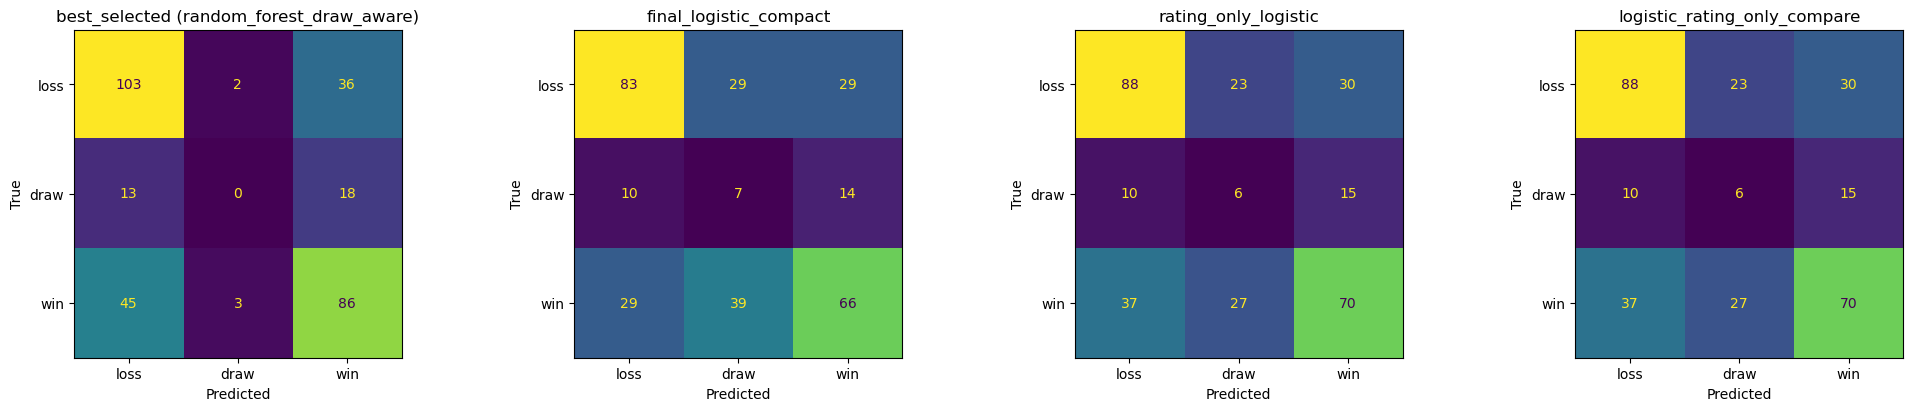

In [154]:
# Confusion matrices: best selected model, final logistic, and rating-delta-only variants (test split).
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

labels = [0, 1, 2]
label_names = ["loss", "draw", "win"]


def _get_feature_view(model_name, X):
    subset_map = {
        "rating_only_logistic": ["rating_delta"],
    }
    cols = subset_map.get(model_name)
    if cols is None:
        return X
    return X[cols]


candidates = []

# 1) Best model selected by balanced accuracy.
if "results_df" in globals() and "trained_models" in globals():
    selected_metric = "val_balanced_accuracy"
    _ranked = results_df.sort_values(selected_metric, ascending=False).reset_index(drop=True)
    best_name = _ranked.iloc[0]["model"]
    best_est = trained_models[best_name]
    candidates.append((f"best_selected ({best_name})", best_est, _get_feature_view(best_name, X_test)))

# 2) Final logistic model.
if "final_model" in globals() and "final_feature_cols" in globals():
    candidates.append(("final_logistic_compact", final_model, X_test[final_feature_cols]))

# 3) Rating-delta-only logistic variants.
if "trained_models" in globals() and "rating_only_logistic" in trained_models:
    candidates.append(("rating_only_logistic", trained_models["rating_only_logistic"], X_test[["rating_delta"]]))
if "compare_models" in globals() and "logistic_rating_only" in compare_models:
    bundle = compare_models["logistic_rating_only"]
    candidates.append(("logistic_rating_only_compare", bundle["model"], X_test[bundle["cols"]]))

# Drop duplicates by title while preserving order.
seen = set()
unique_candidates = []
for title, model, X_part in candidates:
    if title in seen:
        continue
    seen.add(title)
    unique_candidates.append((title, model, X_part))

if not unique_candidates:
    print("No model artifacts found. Run model training cells first.")
else:
    n = len(unique_candidates)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), constrained_layout=True)
    axes = np.array([axes]) if n == 1 else np.array(axes)

    for ax, (title, model, X_part) in zip(axes.ravel(), unique_candidates):
        y_pred = model.predict(X_part)
        cm = confusion_matrix(y_test, y_pred, labels=labels)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
        disp.plot(ax=ax, colorbar=False, values_format="d")
        ax.set_title(title)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    plt.show()


## Notebook scope (frequentist track)

For the final submission story:

- Treat this notebook as the **single-stage baseline track**.
- Keep `xgboost_early_stop` as the simpler one-stage backup reference.
- Use `random_forest_draw_aware` as evidence that draw-targeted tuning can increase draw sensitivity, but it is not the final primary model.
- Final primary choice is reported in `2c_modelling_two_stage.ipynb`.